# Numerical solver for the discrete model with no space, source and death

The numerical solver implements the spatially homogeneous discrete model where macrophages are structured by lipid load, they uptake and offload lipid. The uptake rate is linear decreasing in the lipid load, while the offloading rate is nonlinear, of fourth order with a double root at $s=0$ and at $s=1$.

In [205]:
# Standard Imports
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import solve_ivp

### Model solver

In [206]:
# ODE system
def ode_nospace_source_death(t: float, U: np.ndarray, N, phi, uptake_func, offloading_func) -> np.ndarray:
    """
    ODE system for the discrete model without space, source and death terms. 
    """
    dU = np.zeros_like(U)
    n = np.arange(N + 1)
    uptake = uptake_func(n, N)
    offloading = offloading_func(n, N)

    dU[0] = - N * phi * uptake[0] * U[0] + N * offloading[1] * U[1]

    if N >= 2:
        dU[1:N] = (N * phi * (uptake[0:N-1] * U[0:N-1] - uptake[1:N] * U[1:N]) 
                    + N * (offloading[2:N+1] * U[2:N+1] - offloading[1:N] * U[1:N]))

    dU[N] = N * phi * uptake[N-1] * U[N-1] - N * offloading[N] * U[N]

    return dU
    

In [207]:
# Define parameters and functions
N = 200
kplus = 7
kminus = 2
phi = 64 * kminus / (27 * kplus) - 0.2
print(phi)
tau_star = 30  
t_sweep = 9 / (32 * kminus) * N**(1/3) * tau_star
print(t_sweep)

def offloading_func(n_array, N):
    return 16.0 * kminus * (n_array / N)**2 * (1.0 - n_array / N)**2 

def uptake_func(n_array, N):
    return kplus * (1.0 - n_array / N)

0.4772486772486772
24.67139966617105


### Plot velocity function

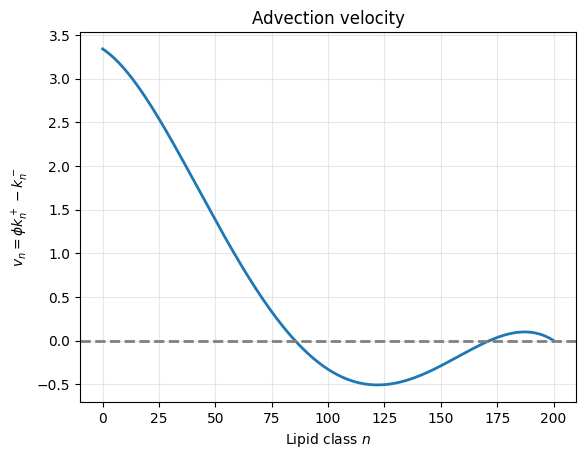

In [208]:
n_array = np.arange(N + 1)

plt.figure()

plt.plot(n_array, phi * uptake_func(n_array, N) - offloading_func(n_array, N), linewidth=2)
plt.axhline(y=0, color='grey', linewidth=2, linestyle='--')

plt.xlabel("Lipid class $n$")
plt.ylabel(r"$v_n=\phi k^+_n - k^-_n$")
plt.title('Advection velocity')

plt.grid(True, alpha=0.3)
plt.show()

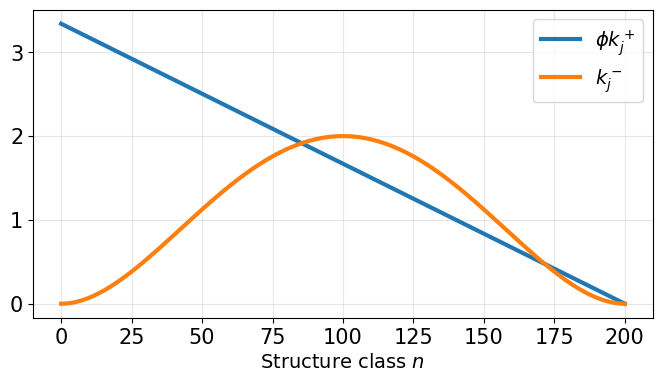

In [209]:
n_array = np.arange(N + 1)

plt.figure(figsize=(8,4))

plt.plot(n_array, phi * uptake_func(n_array, N), linewidth=3, label=r"$\phi k^+_j$")
plt.plot(n_array, offloading_func(n_array, N), linewidth=3, label=r"$k_j^-$")

plt.xlabel("Structure class $n$", fontsize=14)
plt.legend(fontsize=14)

plt.tick_params(
    axis="both",
    which="major",
    labelsize=15
)

plt.grid(True, alpha=0.3)
plt.show()

#### Initial conditions

In [210]:
# Initial conditions

# Initial conditions
# Uniformly distributed 
# U0 = np.ones(N + 1) 

# Delta distribution centred at n0
# n0 = 172
# U0 = np.zeros(N + 1)
# U0[n0] = 1

# Gaussian disttribution centred at n0 with variance sigma
n0 = 133
sigma = 5
U0 = np.exp(-(n_array - n0)**2 / (2 * sigma**2))

# Normalize so total probability = 1
U0 = U0 / np.sum(U0)

#### Solve the model

In [211]:
# Solve model until approximately steady state

# Steady-state tolerance
steady_tol = 1e-8

def steady_state_event(t, U, N, phi, uptake_func, offloading_func):
    dU = ode_nospace_source_death(t, U, N, phi, uptake_func, offloading_func)

    # Event occurs when max |dU/dt| falls below the tolerance
    return np.max(np.abs(dU)) - steady_tol

steady_state_event.terminal = True
steady_state_event.direction = -1

# A large upper bound is still required by solve_ivp.
# The event should terminate integration before reaching it.
t_max = 100

sol = solve_ivp(
    ode_nospace_source_death,
    (0, t_max),
    U0,
    args=(N, phi, uptake_func, offloading_func),
    events=steady_state_event,
    rtol=1e-8,
    atol=1e-10,
    dense_output=True
)

print(f"Solver stopped at t = {sol.t[-1]:.6g}")
print(
    "max |dU/dt| =",
    np.max(np.abs(
        ode_nospace_source_death(
            sol.t[-1], sol.y[:, -1],
            N, phi, uptake_func, offloading_func
        )
    ))
)

Solver stopped at t = 100
max |dU/dt| = 2.8128957207940175e-07


### Find roots of velocity function

In [212]:
def find_roots(phi, kplus, kminus, tol=1e-12):
    C = kplus * phi / (16 * kminus)
    C_star = 4 / 27

    # Special case at the double root
    if np.isclose(C, C_star, rtol=0, atol=tol):
        roots = np.array([2/3])
    else:
        # s^3 - s^2 + C = 0
        coefficients = [1, -1, 0, C]
        roots_all = np.roots(coefficients)

        roots = roots_all[
            (np.abs(roots_all.imag) < 1e-10) &
            (roots_all.real >= 0) &
            (roots_all.real < 1)
        ].real

        roots = np.unique(np.round(roots, decimals=12))

    return np.sort(roots)

roots = find_roots(phi, kplus, kminus)
print(roots * N)

[ 85.35026172 171.65564273]


### Bifurcation diagram

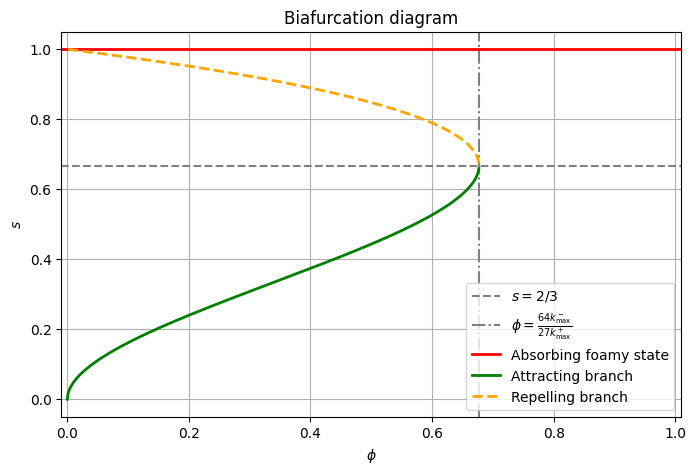

In [213]:
phis = np.linspace(0, 1, 1001)

root1 = np.full_like(phis, np.nan, dtype=float)
root2 = np.full_like(phis, np.nan, dtype=float)

for i, phi_current in enumerate(phis):
    roots_bif = find_roots(phi_current, kplus, kminus)

    if len(roots_bif) == 1:
        root1[i] = roots_bif[0]
    elif len(roots_bif) == 2:
        root1[i] = roots_bif[0]
        root2[i] = roots_bif[1]

plt.figure(figsize=(8,5))
plt.axhline(y=2/3, color='grey', linestyle='--', linewidth=1.5, label="$s=2/3$")
plt.axvline(x=64 * kminus / (27 * kplus), label=r"$\phi=\frac{64k_{\text{max}}^-}{27k_{\text{max}}^+}$", linestyle='-.', color='grey')
plt.axhline(y=1, label='Absorbing foamy state', color='red', linewidth=2)
plt.plot(phis, root1, label='Attracting branch', color='green', linewidth=2)
plt.plot(phis, root2, label='Repelling branch', linestyle='--', color='orange', linewidth=2)

plt.xlabel(r'$\phi$')
plt.ylabel(r'$s$')
plt.title("Biafurcation diagram")
plt.xlim(-0.01, 1.01)

plt.legend()
plt.grid()
plt.show()

### Plotting

In [214]:
time_points = [0.01, 0.05, 0.1, 0.5, 1.0, sol.t[-1]]

# Choose a sequential colormap (e.g., 'Blues', 'Reds', 'Greens', 'Purples')
cmap = plt.get_cmap('Blues')

# Generate the colors. 
# We map from 0.3 to 1.0 so the "lightest" color isn't completely white and invisible!
colors = cmap(np.linspace(0.3, 1.0, len(time_points)))

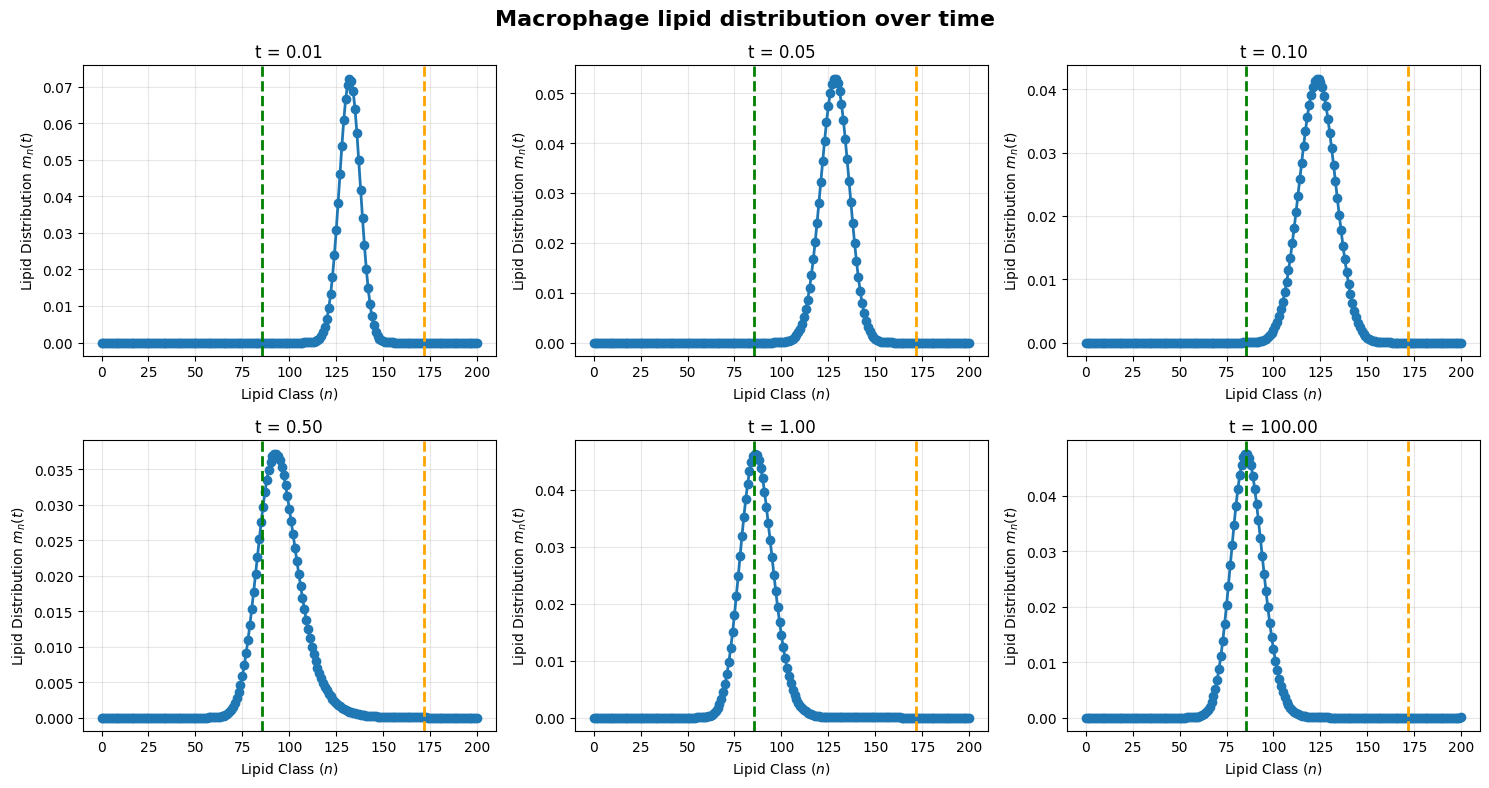

In [215]:
num_plots = len(time_points)

# Dynamically calculate grid size
ncols = min(3, num_plots)
nrows = math.ceil(num_plots / ncols)

# Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

# Flatten axes to 1D array for easy looping
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for j, time in enumerate(time_points):
    ax = axes[j]

    # Find the index of the closest time point in the solution
    idx = np.argmin(np.abs(sol.t - time))
    actual_t = sol.t[idx]

    ax.plot(n_array, sol.y[:, idx], linewidth=2, marker='o')

    if len(roots) == 0:
        ax.axvline(x=N, color="red", linestyle="--",linewidth=2,label=r"s-steady state")
    elif len(roots) == 1:
        ax.axvline(x=roots[0] * N, color="orange", linestyle="--",linewidth=2,label=r"s-steady state")
    elif len(roots) == 2:
        ax.axvline(x=roots[0] * N, color="green", linestyle="--",linewidth=2,label=r"s-steady state")
        ax.axvline(x=roots[1] * N, color="orange", linestyle="--",linewidth=2)

    ax.set_xlabel("Lipid Class ($n$)")
    ax.set_ylabel("Lipid Distribution $m_n(t)$")
    ax.set_title(f"t = {actual_t:.2f}")
    ax.grid(True, alpha=0.3)

plt.suptitle("Macrophage lipid distribution over time", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)

In [216]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

n_frames = 200
# More frames near t=0, fewer later
s = np.linspace(0, 1, n_frames)
t_frames = sol.t[-1] * s**5

U_frames = sol.sol(t_frames)

fig, ax = plt.subplots(figsize=(8, 5))

# Add circular markers
line, = ax.plot(
    n_array,
    U_frames[:, 0],
    marker='o',
    linestyle = None,
    markersize=5
)

ax.set_xlabel(r"$n$", fontsize=12)
ax.set_ylabel(r"$m_n(t)$", fontsize=12)
ax.set_title("Evolution of the macrophage lipid distribution", fontsize=14, fontweight='bold')
#ax.grid(True)

ax.set_xlim(n_array.min(), n_array.max())

time_text = ax.text(
    0.05,
    0.92,
    "",
    transform=ax.transAxes
)

def update(frame):

    # Current distribution
    U_current = U_frames[:, frame]

    # Update distribution
    line.set_ydata(U_current)

    # Update y-axis based on current maximum
    current_max = np.max(U_current)
    ax.set_ylim(0, 1.1 * current_max)

    # Update time
    time_text.set_text(f"t = {t_frames[frame]:.3f}")

    return line, time_text

ani = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=100,
    blit=False
)

plt.close(fig)

HTML(ani.to_jshtml())

### Healthy vs unhealthy cells

In [217]:
m_healthy = np.zeros(len(sol.t))
m_unhealthy = np.zeros(len(sol.t))

if len(roots) > 0:

    n_unstable = roots[-1] * N

    healthy = n_array <= n_unstable
    unhealthy = n_array > n_unstable

    m_healthy = np.sum(sol.y[healthy, :], axis=0)
    m_unhealthy = np.sum(sol.y[unhealthy, :], axis=0)

else:

    m_unhealthy = np.sum(sol.y, axis=0)

m_tot = np.sum(sol.y, axis=0)

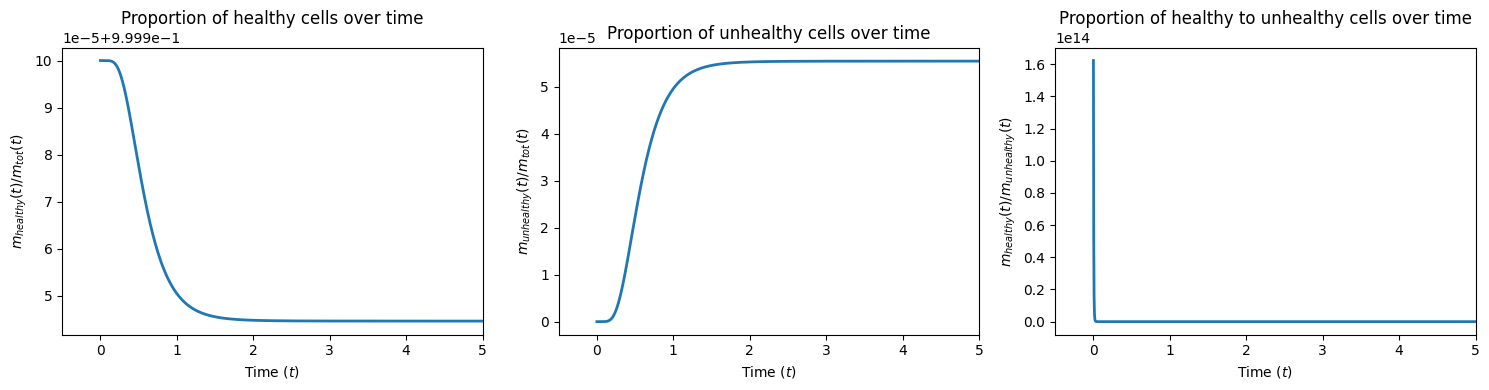

In [218]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

axes[0].plot(sol.t, m_healthy/m_tot, linewidth=2)
axes[0].set_xlabel("Time ($t$)")
axes[0].set_ylabel(r"$m_{healthy}(t)/m_{tot}(t)$")
axes[0].set_title("Proportion of healthy cells over time")

axes[1].plot(sol.t, m_unhealthy/m_tot, linewidth=2)
axes[1].set_xlabel("Time ($t$)")
axes[1].set_ylabel(r"$m_{unhealthy}(t)/m_{tot}(t)$")
axes[1].set_title("Proportion of unhealthy cells over time")

axes[2].plot(sol.t, m_healthy/m_unhealthy, linewidth=2)
axes[2].set_xlabel("Time ($t$)")
axes[2].set_ylabel(r"$m_{healthy}(t)/m_{unhealthy}(t)$")
axes[2].set_title("Proportion of healthy to unhealthy cells over time")

for ax in axes:
    ax.set_xlim(-0.5, 5)

plt.tight_layout()
plt.show()

### Heatmaps

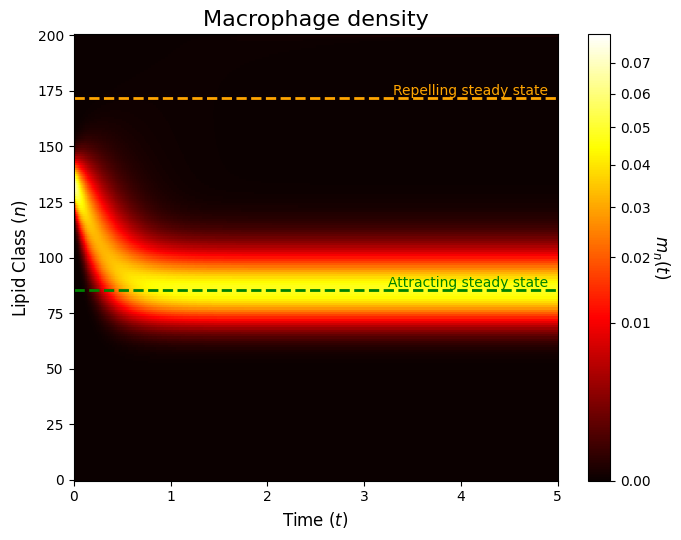

In [219]:
from matplotlib.colors import PowerNorm

fig, ax = plt.subplots(figsize=(7, 5.5))

index = -1

mask = sol.t <= 5

t_visible = sol.t[mask]
y_visible = sol.y[:, mask]

n_plot = 1000

indices = np.linspace(0, len(t_visible) - 1, n_plot, dtype=int)

t_plot = t_visible[indices]
y_plot = y_visible[:, indices]

mesh = ax.pcolormesh(
    t_plot,
    n_array,
    y_plot,
    cmap='hot',
    shading='auto',
    norm=PowerNorm(gamma=0.5, vmin=0, vmax=np.max(y_plot))
)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("$m_{n}(t)$", rotation=270, labelpad=15, fontsize=12)


# if len(roots) == 0:
#     ax.axhline(y=N, color="red", linestyle="--",linewidth=2)
#     ax.text(t_visible[-1] - 0.1, N, "Stable steady state", color="red", ha="right", va="bottom")
if len(roots) == 1:
    n_stable = roots[0] * N
    ax.axhline(y=n_stable, color="orange", linestyle="--",linewidth=2)
    ax.text(t_visible[-1] - 0.1, n_stable, "Steady state", color="orange", ha="right", va="bottom")
elif len(roots) == 2:
    n_stable = roots[0] * N
    n_unstable = roots[1] * N
    ax.axhline(y=n_stable, color="green", linestyle="--",linewidth=2)
    ax.text(t_visible[-1] - 0.1, n_stable, "Attracting steady state", color="green", ha="right", va="bottom")
    ax.axhline(y=n_unstable, color="orange", linestyle='--', linewidth=2)
    ax.text(t_visible[-1] - 0.1, n_unstable, "Repelling steady state", color="orange", ha="right", va="bottom")

ax.set_title("Macrophage density", fontsize=16)
ax.set_xlabel("Time ($t$)", fontsize=12)
ax.set_ylabel("Lipid Class ($n$)", fontsize=12)

#ax.set_ylim(0, 2)
#ax.set_xlim(0, 5)

plt.tight_layout()
plt.show()

### $\phi$ parameter sweep

In [220]:
# Steady state distribution for different values of phi
phi_star = 64 * kminus / (27 * kplus)

phis_sweep = np.concatenate([
    np.linspace(0, 0.5 * phi_star, 40),
    np.linspace(0.5 * phi_star, 0.9 * phi_star, 20),
    np.linspace(0.9 * phi_star, 0.99 * phi_star, 20),
    np.linspace(0.99 * phi_star, 1.01 * phi_star, 40),
    np.linspace(1.01 * phi_star, 1, 10)])

phis_sweep = np.unique(phis_sweep)
sol_steady_state = np.zeros((N + 1, len(phis_sweep)))

t_sweep = t_sweep

for i, phi_current in enumerate(phis_sweep):

    sol_sweep = solve_ivp(ode_nospace_source_death, (0, t_sweep), U0, args=(N, phi_current, uptake_func, offloading_func), rtol=1e-8, atol=1e-10,
            t_eval=[t_sweep])

    sol_steady_state[:,i] = sol_sweep.y[:, 0]

    

KeyboardInterrupt: 

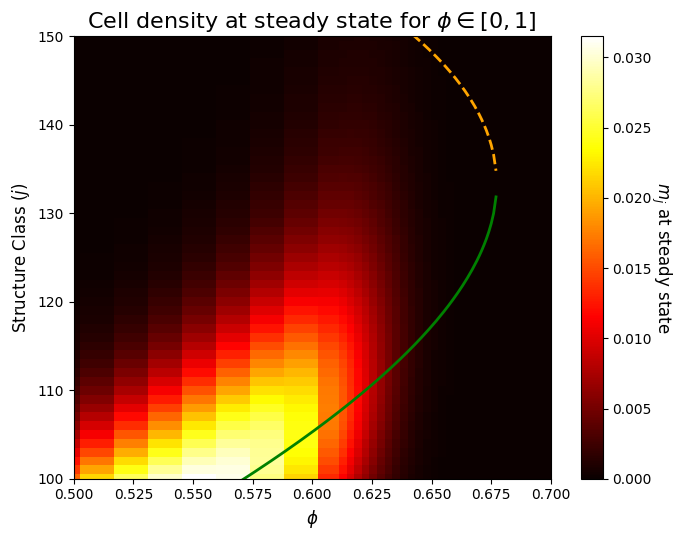

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))

mesh = plt.pcolormesh(phis_sweep, n_array[100:151],  sol_steady_state[100:151, :],
                     cmap='hot', shading='auto') # hot, OrRd, Reds, plasma # * model.v

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("$m_{j}$ at steady state", rotation=270, labelpad=15, fontsize=12)

ax.plot(phis, N * root1, label='Attracting branch', color='green', linewidth=2)
ax.plot(phis, N * root2, label='Repelling branch', linestyle='--', color='orange', linewidth=2)

ax.set_title(r"Cell density at steady state for $\phi\in[0,1]$", fontsize=16)
ax.set_xlabel(r"$\phi$", fontsize=12)
ax.set_ylabel("Structure Class ($j$)", fontsize=12)

ax.set_ylim(100, 150)
ax.set_xlim(0.5, 0.7)

plt.tight_layout()
plt.show()

In [221]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from IPython.display import Video

# ---------------------------------------------------------
# Phi sweep
# ---------------------------------------------------------
phi_star = 64 * kminus / (27 * kplus)

phis_sweep = np.concatenate([
    np.linspace(0, 0.5 * phi_star, 40),
    np.linspace(0.5 * phi_star, 0.9 * phi_star, 20),
    np.linspace(0.9 * phi_star, 0.99 * phi_star, 20),
    np.linspace(0.99 * phi_star, 1.01 * phi_star, 40),
    np.linspace(1.01 * phi_star, 1, 10)
])

phis_sweep = np.unique(phis_sweep)

# ---------------------------------------------------------
# Time points to save
# ---------------------------------------------------------
t_sweep = t_sweep

# Use plenty of uniformly spaced solution points
n_time = 1000
t_eval_sweep = np.linspace(0, t_sweep, n_time)

sol_time = np.zeros(
    (n_time, N + 1, len(phis_sweep))
)


# ---------------------------------------------------------
# Solve for every phi
# ---------------------------------------------------------
for i, phi_current in enumerate(phis_sweep):

    sol_sweep = solve_ivp(
        ode_nospace_source_death,
        (0, t_sweep),
        U0,
        args=(
            N,
            phi_current,
            uptake_func,
            offloading_func
        ),
        rtol=1e-8,
        atol=1e-10,
        t_eval=t_eval_sweep
    )

    sol_time[:, :, i] = sol_sweep.y.T

### Find $\phi_{\text{transition}}$ numerically

In [222]:
def unstable_root(phi, kplus, kminus):
    roots = find_roots(phi, kplus, kminus)

    if len(roots) < 2:
        return np.nan

    return roots[-1]

def escaped_mass(m, n_r):

    if np.isnan(n_r):
        return np.nan

    N_local = len(m) - 1

    # cumulative mass over n = 0,...,N-1
    C = np.cumsum(m[:N_local])

    n_values = np.arange(N_local)   # 0,...,N-1

    # mass at/below the unstable branch
    C_nr = np.interp(n_r, n_values, C)

    # exclude n=N
    return C[-1] - C_nr

m_final = sol_time[-1, :, :]

# Find escaped mass for each phi <= phi_c
E = np.full(len(phis_sweep), np.nan)

for i, phi in enumerate(phis_sweep):

    if phi >= phi_star:
        continue

    roots = find_roots(phi, kplus, kminus)

    if len(roots) < 1:
        continue

    s_r = roots[-1]
    n_r = s_r * N

    E[i] = escaped_mass(m_final[:, i], n_r)

In [223]:
# Find phi_transition through the maximum of the escaped mass
mask = (
    np.isfinite(E)
    & (phis_sweep > 0)
    & (phis_sweep < phi_star)
)

phi_sub = phis_sweep[mask]
E_sub = E[mask]

i_tr = np.argmax(E_sub)

phi_tr = phi_sub[i_tr]

print("phi_c =", phi_star)
print("phi_tr =", phi_tr)
print("phi_c - phi_tr =", phi_star - phi_tr)

phi_c = 0.6772486772486772
phi_tr = 0.625563909774436
phi_c - phi_tr = 0.05168476747424122


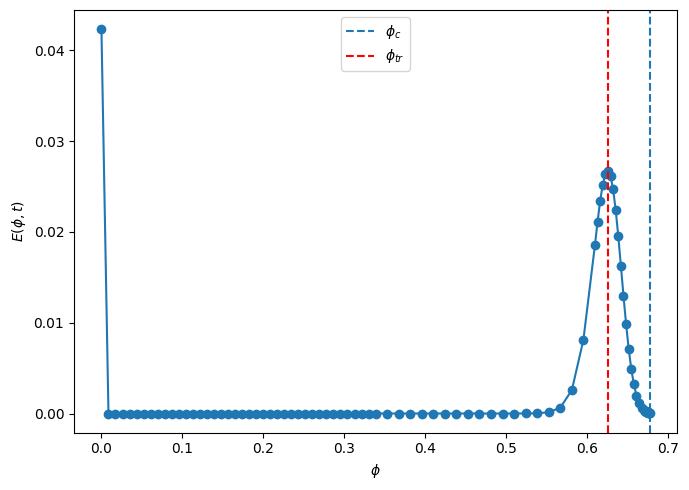

In [224]:
# Plot escaped mass
mask = np.isfinite(E)

plt.figure(figsize=(7, 5))
plt.plot(phis_sweep[mask], E[mask], 'o-')
plt.axvline(phi_star, linestyle='--', label=r'$\phi_c$')
plt.axvline(phi_tr, linestyle='--', color='red', label=r'$\phi_{tr}$')
plt.xlabel(r'$\phi$')
plt.ylabel(r'$E(\phi,t)$')
plt.legend()
plt.tight_layout()
plt.show()

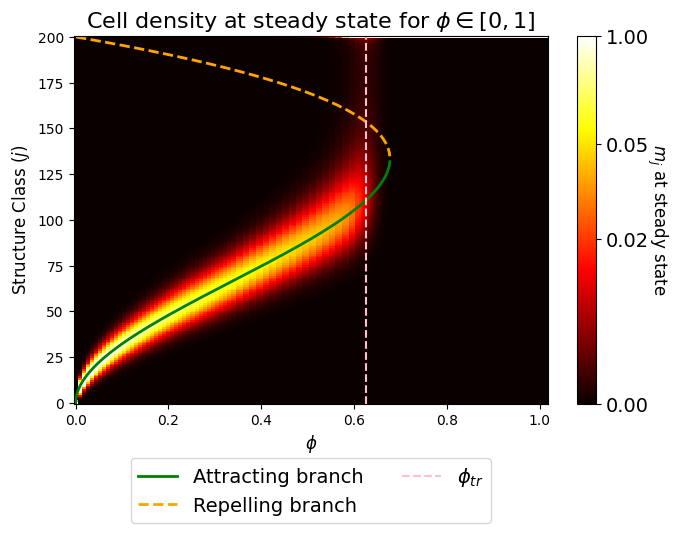

In [225]:
from matplotlib.colors import FuncNorm

fig, ax = plt.subplots(figsize=(7, 5.5))

vmin = 0.0
v_sat = 0.1
vmax = np.max(sol_time[-1, :, :])
gamma = 0.5  # Adjust gamma < 1 for contrast below 0.004, or 1.0 for linear

# 2. Forward function: [vmin, vmax] -> [0, 1]
def forward(x):
    # Clip upper boundary to saturate at 1.0
    x_clipped = np.clip(x, vmin, v_sat)
    return (x_clipped / v_sat) ** gamma

# 3. Inverse function: [0, 1] -> [vmin, vmax] (needed for colourbar ticks)
def inverse(y):
    return v_sat * (np.clip(y, 0, 1) ** (1.0 / gamma))

# 4. Custom Norm
custom_norm = FuncNorm((forward, inverse), vmin=vmin, vmax=vmax)

mesh = plt.pcolormesh(phis_sweep, n_array[:],  sol_time[-1, :, :],
                     cmap='hot', shading='auto', norm=custom_norm) # hot, OrRd, Reds, plasma # * model.v

# Colourbar definition
cbar = fig.colorbar(mesh, ax=ax, extend='neither')
cbar.set_label(r"$m_{j}(t)$", rotation=270, labelpad=25, fontsize=18)
cbar.ax.tick_params(labelsize=14)

# Explicitly set ticks so both the threshold and the true maximum are legible
cbar.set_ticks([0.0, 0.02, 0.05, vmax])

# cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("$m_{j}$ at steady state", rotation=270, labelpad=15, fontsize=12)

ax.plot(phis, N * root1, label='Attracting branch', color='green', linewidth=2)
ax.plot(phis, N * root2, label='Repelling branch', linestyle='--', color='orange', linewidth=2)
ax.axvline(phi_tr, linestyle='--', color='pink', label=r'$\phi_{tr}$')

ax.set_title(r"Cell density at steady state for $\phi\in[0,1]$", fontsize=16)
ax.set_xlabel(r"$\phi$", fontsize=12)
ax.set_ylabel("Structure Class ($j$)", fontsize=12)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=True,
    fontsize=14
)

# ax.set_ylim(100, 150)
# ax.set_xlim(0.5, 0.7)

plt.tight_layout()
plt.show()

### Video

In [226]:
from matplotlib.colors import FuncNorm

# =========================================================
# VIDEO FRAME SELECTION
# =========================================================

t_transition = 5.0

# ---------------------------------------------------------
# PART 1: t = 0 -> 5
# Many frames + power-law acceleration
# ---------------------------------------------------------

n_frames_early = 500
power = 10.0

s = np.linspace(0, 1, n_frames_early)

t_early = t_transition * s**power

# ---------------------------------------------------------
# PART 2: t = 5 -> t_sweep
# Very few frames -> very fast
# ---------------------------------------------------------

n_frames_late = 75

t_late = np.linspace(
    t_transition,
    t_sweep,
    n_frames_late
)

# ---------------------------------------------------------
# Combine
# ---------------------------------------------------------

t_animation = np.concatenate([
    t_early,
    t_late[1:]   # avoid repeating t=5
])

# Convert desired times into solver indices
frame_indices = np.searchsorted(
    t_eval_sweep,
    t_animation
)

frame_indices = np.clip(
    frame_indices,
    0,
    len(t_eval_sweep) - 1
)

frame_indices = np.unique(frame_indices)

# ---------------------------------------------------------
# Global colour scale
# ---------------------------------------------------------
# vmin = 0
# vmax = np.max(sol_time)
# 1. Define limits and threshold
vmin = 0.0
v_sat = 0.1
vmax = np.max(sol_time)
gamma = 0.5  

# 2. Forward function: [vmin, vmax] -> [0, 1]
def forward(x):
    # Clip upper boundary to saturate at 1.0
    x_clipped = np.clip(x, vmin, v_sat)
    return (x_clipped / v_sat) ** gamma

# 3. Inverse function: [0, 1] -> [vmin, vmax] (needed for colourbar ticks)
def inverse(y):
    return v_sat * (np.clip(y, 0, 1) ** (1.0 / gamma))

# 4. Custom Norm
custom_norm = FuncNorm((forward, inverse), vmin=vmin, vmax=vmax)

# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

initial_data = sol_time[0, :, :]

# mesh = ax.pcolormesh(
#     phis_sweep,
#     n_array,
#     initial_data,
#     cmap="hot",
#     shading="auto",
#     norm=PowerNorm(gamma=0.3, vmin=vmin, vmax=vmax)
# )

# # ---------------------------------------------------------
# # Colourbar
# # ---------------------------------------------------------
# cbar = fig.colorbar(mesh, ax=ax)

# cbar.set_label(
#     r"$m_j(t)$",
#     rotation=270,
#     labelpad=25,
#     fontsize=18
# )

# cbar.ax.tick_params(
#     labelsize=14
# )

mesh = ax.pcolormesh(
    phis_sweep,
    n_array,
    initial_data,
    cmap="hot",
    shading="auto",
    norm=custom_norm
)

# Colourbar definition
cbar = fig.colorbar(mesh, ax=ax, extend='neither')
cbar.set_label(r"$m_{j}(t)$", rotation=270, labelpad=25, fontsize=18)
cbar.ax.tick_params(labelsize=14)

# Explicitly set ticks so both the threshold and the true maximum are legible
cbar.set_ticks([0.0, 0.05, vmax])
# cbar.set_ticklabels(["0", "0.001", "0.002", "0.004 (sat)", f"{vmax:.3f}"])

# ---------------------------------------------------------
# Plot the analytical branches
# ---------------------------------------------------------
ax.plot(
    phis,
    N * root1,
    label="Attracting branch",
    color="green",
    linewidth=1
)

ax.plot(
    phis,
    N * root2,
    label="Repelling branch",
    linestyle="--",
    color="orange",
    linewidth=1
)

ax.axvline(phi_tr, linestyle='--', color='pink', label=r'$\phi_{tr}$')

# ax.axhline(
#     y=N,
#     color="cyan",
#     linestyle="--",
#     linewidth=2,
#     label="Absorbing state"
# )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=True,
    fontsize=14
)

plt.subplots_adjust(bottom=0.18)

ax.set_xlabel(r"$\phi$", fontsize=18)
ax.set_ylabel("Structure Class ($j$)", fontsize=18)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=15
)

#ax.set_ylim(5, N - 1)

title = ax.set_title(
    f"Cell density at t = {t_eval_sweep[0]:.2f}",
    fontsize=20,
    pad=12
)

# fig.suptitle(
#     r"Cell density evolution for $\phi\in[0,1]$",
#     fontsize=14,
#     fontweight="bold"
# )

plt.subplots_adjust(
    left=0.12,
    right=0.90,
    top=0.90,
    bottom=0.20
)

plt.tight_layout()

def update(frame_idx):
    data = sol_time[frame_idx, :, :]
    mesh.set_array(data.ravel())
    title.set_text(
        f"Cell density at t = {t_eval_sweep[frame_idx]:.2f}"
    )
    return mesh, title

frame_interval = 75

anim = animation.FuncAnimation(
    fig,
    update,
    frames=frame_indices,
    interval=frame_interval,
    blit=False,
    repeat=False
)

writer = FFMpegWriter(
    fps=1000 / frame_interval,
    bitrate=3000
)

anim.save(
    "phi_sweep_evolution_nosourcedeath.mp4",
    writer=writer,
    dpi=150
)

plt.close(fig)

print("Saved as phi_sweep_evolution_nosourcedeath.mp4")

Saved as phi_sweep_evolution_nosourcedeath.mp4


### Checking inner scaling

In [239]:
# ---------------------------------------------------------
# Phi sweep: only 0.5 <= phi < phi_c
# ---------------------------------------------------------
phi_star = 64 * kminus / (27 * kplus)

phis_sweep_scaling = np.linspace(
    0.5,
    phi_star,
    200,
    endpoint=False
)

N_ref = 200
t_ref = 25.0
tau_ref = 32 * kminus / 9 * N_ref**(-1/3) * t_ref

from scipy.sparse import diags

def birth_death_sparsity(N):
    size = N + 1

    return diags(
        diagonals=[
            np.ones(size - 1),
            np.ones(size),
            np.ones(size - 1)
        ],
        offsets=[-1, 0, 1],
        shape=(size, size),
        format="csc"
    )


def compute_phi_transition(
    N,
    kplus,
    kminus,
    uptake_func,
    offloading_func,
    U0,
    tau_ref,
):

    phi_c = 64 * kminus / (27 * kplus)

    # Same inner time for every N
    t_sweep_scaling = (
        9 / (32 * kminus)
        * N**(1/3)
        * tau_ref
    )

    phis_scaling = phis_sweep_scaling

    E = np.full(len(phis_scaling), np.nan)

    for i, phi in enumerate(phis_scaling):

        # We only define E below phi_c
        if phi >= phi_c:
            continue

        J_sparsity = birth_death_sparsity(N)

        sol = solve_ivp(
            ode_nospace_source_death,
            (0, t_sweep_scaling),
            U0,
            args=(N, phi, uptake_func, offloading_func),
            method="BDF",
            jac_sparsity=J_sparsity,
            rtol=1e-6,
            atol=1e-9,
            t_eval=[t_sweep_scaling]
        )

        m_final = sol.y[:, -1]

        roots = find_roots(phi, kplus, kminus)

        if len(roots) < 2:
            continue

        # Upper root = repelling branch
        n_r = N * roots[-1]

        E[i] = escaped_mass(m_final, n_r)

    # Numerical maximum
    i_peak = np.argmax(E)

    phi_tr_grid = phis_scaling[i_peak]

    return {
        "N": N,
        "t": t_sweep_scaling,
        "tau": tau_ref,
        "phi_c": phi_c,
        "phi_tr": phi_tr_grid,
        "delta_phi": phi_c - phi_tr_grid,
        "phi": phi,
        "E": E
    }

In [240]:
N_values = [50, 100, 200, 400, 800, 1600, 3200]

# Reference simulation
N_ref = 200
t_ref = 25.0

tau_ref = (
    32 * kminus / 9
    * N_ref**(-1/3)
    * t_ref
)

results = []

for N_current in N_values:

    U0_N = np.ones(N_current + 1) 
    U0_N = U0_N / np.sum(U0_N)

    result = compute_phi_transition(
        N=N_current,
        kplus=kplus,
        kminus=kminus,
        uptake_func=uptake_func,
        offloading_func=offloading_func,
        U0=U0_N,
        tau_ref=tau_ref
    )

    results.append(result)

    print(
        f"N={N_current:5d}, "
        f"t={result['t']:.3f}, "
        f"phi_tr={result['phi_tr']:.8f}, "
        f"phi_c={result['phi_c']:.8f}, "
        f"delta_phi={result['delta_phi']:.6e}"
    )

N=   50, t=15.749, phi_tr=0.55140212, phi_c=0.67724868, delta_phi=1.258466e-01
N=  100, t=19.843, phi_tr=0.59571429, phi_c=0.67724868, delta_phi=8.153439e-02
N=  200, t=25.000, phi_tr=0.62584656, phi_c=0.67724868, delta_phi=5.140212e-02
N=  400, t=31.498, phi_tr=0.64534392, phi_c=0.67724868, delta_phi=3.190476e-02
N=  800, t=39.685, phi_tr=0.65686508, phi_c=0.67724868, delta_phi=2.038360e-02
N= 1600, t=50.000, phi_tr=0.66484127, phi_c=0.67724868, delta_phi=1.240741e-02
N= 3200, t=62.996, phi_tr=0.66927249, phi_c=0.67724868, delta_phi=7.976190e-03


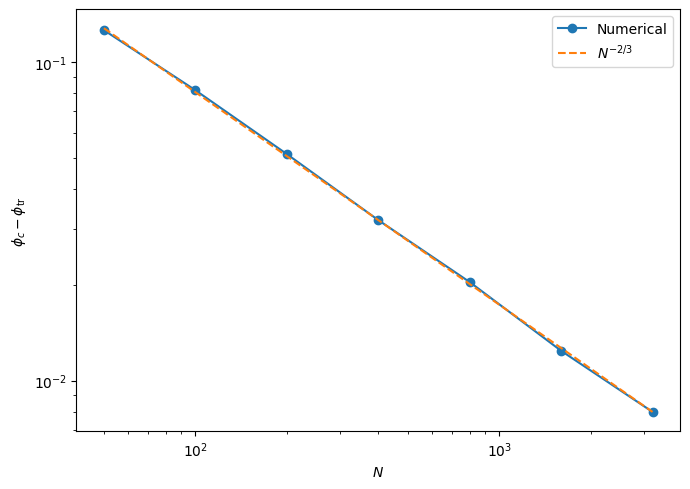

In [241]:
Ns = np.array([r["N"] for r in results])
delta_phi = np.array([r["delta_phi"] for r in results])

plt.figure(figsize=(7,5))

plt.loglog(Ns, delta_phi, 'o-', label='Numerical')

# reference N^(-2/3) line
C_ref = delta_phi[-1] * Ns[-1]**(2/3)
N_fine = np.linspace(Ns.min(), Ns.max(), 500)

plt.loglog(
    N_fine,
    C_ref * N_fine**(-2/3),
    '--',
    label=r'$N^{-2/3}$'
)

plt.xlabel(r'$N$')
plt.ylabel(r'$\phi_c-\phi_{\rm tr}$')
plt.legend()
plt.tight_layout()
plt.show()

In [242]:
x = np.log(Ns)
y = np.log(delta_phi)

p, logC = np.polyfit(x, y, 1)

print("Fitted exponent:", p)
print("Predicted exponent:", -2/3)

Fitted exponent: -0.6680821236163031
Predicted exponent: -0.6666666666666666


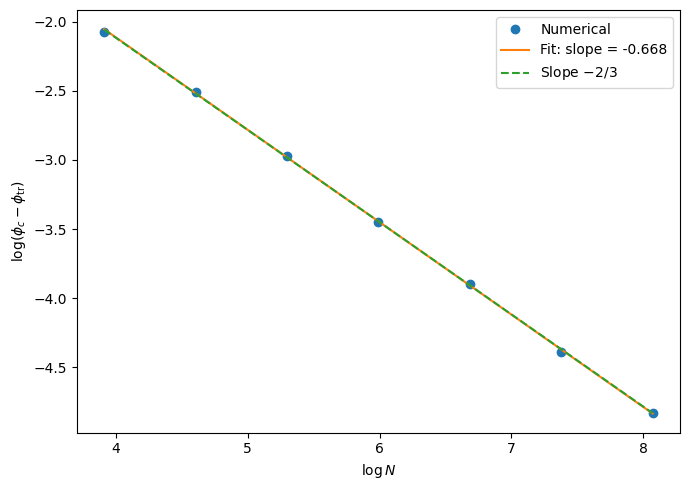

In [243]:
plt.figure(figsize=(7,5))

plt.plot(x, y, 'o', label='Numerical')

x_fit = np.linspace(x.min(), x.max(), 200)

plt.plot(
    x_fit,
    logC + p*x_fit,
    '-',
    label=fr'Fit: slope = {p:.3f}'
)

# theoretical line, vertically shifted for comparison
logC_theory = np.mean(y + (2/3)*x)

plt.plot(
    x_fit,
    logC_theory - (2/3)*x_fit,
    '--',
    label=r'Slope $-2/3$'
)

plt.xlabel(r'$\log N$')
plt.ylabel(r'$\log(\phi_c-\phi_{\rm tr})$')
plt.legend()
plt.tight_layout()
plt.show()

In [244]:
logN = np.log(Ns)
logdphi = np.log(delta_phi)

slope, intercept = np.polyfit(logN, logdphi, 1)

print("Fitted exponent =", slope)
print("Expected exponent =", -2/3)

Fitted exponent = -0.6680821236163031
Expected exponent = -0.6666666666666666


In [245]:
logdphi_fit = slope * logN + intercept

SS_res = np.sum((logdphi - logdphi_fit)**2)
SS_tot = np.sum((logdphi - np.mean(logdphi))**2)

R2 = 1 - SS_res / SS_tot

print("R^2 =", R2)

R^2 = 0.9998027811480352


In [246]:
Ns = np.array([r["N"] for r in results])
delta_phi = np.array([r["delta_phi"] for r in results])

psi_tr_num = (
    9 / 64
    * (kplus / kminus)
    * Ns**(2/3)
    * delta_phi
)

for N, psi in zip(Ns, psi_tr_num):
    print(f"N = {N:4d},  psi_tr = {psi:.6f}")

N =   50,  psi_tr = 0.840657
N =  100,  psi_tr = 0.864579
N =  200,  psi_tr = 0.865230
N =  400,  psi_tr = 0.852497
N =  800,  psi_tr = 0.864579
N = 1600,  psi_tr = 0.835394
N = 3200,  psi_tr = 0.852497


### Escape time

In [247]:
from scipy.integrate import quad

def U(x, psi):
    return psi*x - x**3/3

def inner_integral(y, psi):
    f = lambda z: np.exp(-2 * U(z, psi))
    return quad(f, -np.inf, y, epsabs=1e-10, epsrel=1e-10)[0]

def T_escape(psi):
    
    lower = -np.sqrt(psi)
    upper = np.sqrt(psi)

    def integrand(y):
        return (
            np.exp(2 * U(y, psi))
            * inner_integral(y, psi)
        )

    result = quad(
        integrand,
        lower,
        upper,
        epsabs=1e-9,
        epsrel=1e-9
    )[0]

    return 2 * result

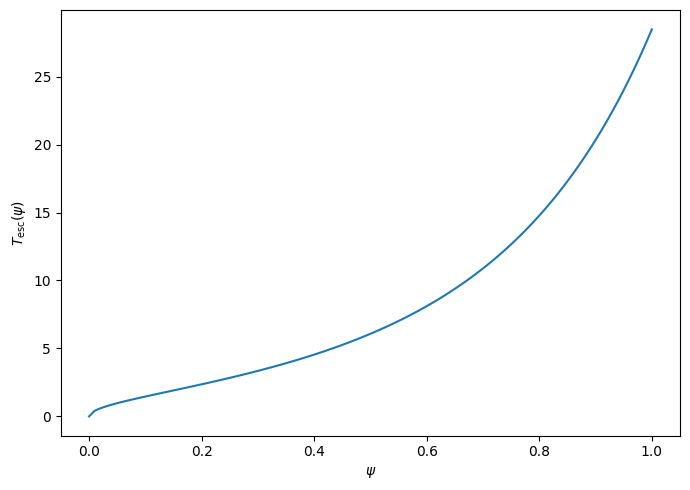

In [248]:
psi_values = np.linspace(0, 1, 100)

T_values = np.array([
    T_escape(psi)
    for psi in psi_values
])

plt.figure(figsize=(7, 5))

plt.plot(psi_values, T_values)
#plt.axvline(0.85, color='red', linestyle='--', label=r'$\psi_{\rm tr}$')

plt.xlabel(r'$\psi$')
plt.ylabel(r'$T_{\rm esc}(\psi)$')

plt.tight_layout()
plt.show()

In [249]:
psi_num = 0.85

print("T_escape(psi_num) =", T_escape(psi_num))

T_escape(psi_num) = 17.301697196505096


### Boundary conditions

IndexError: index 3198 is out of bounds for axis 0 with size 201

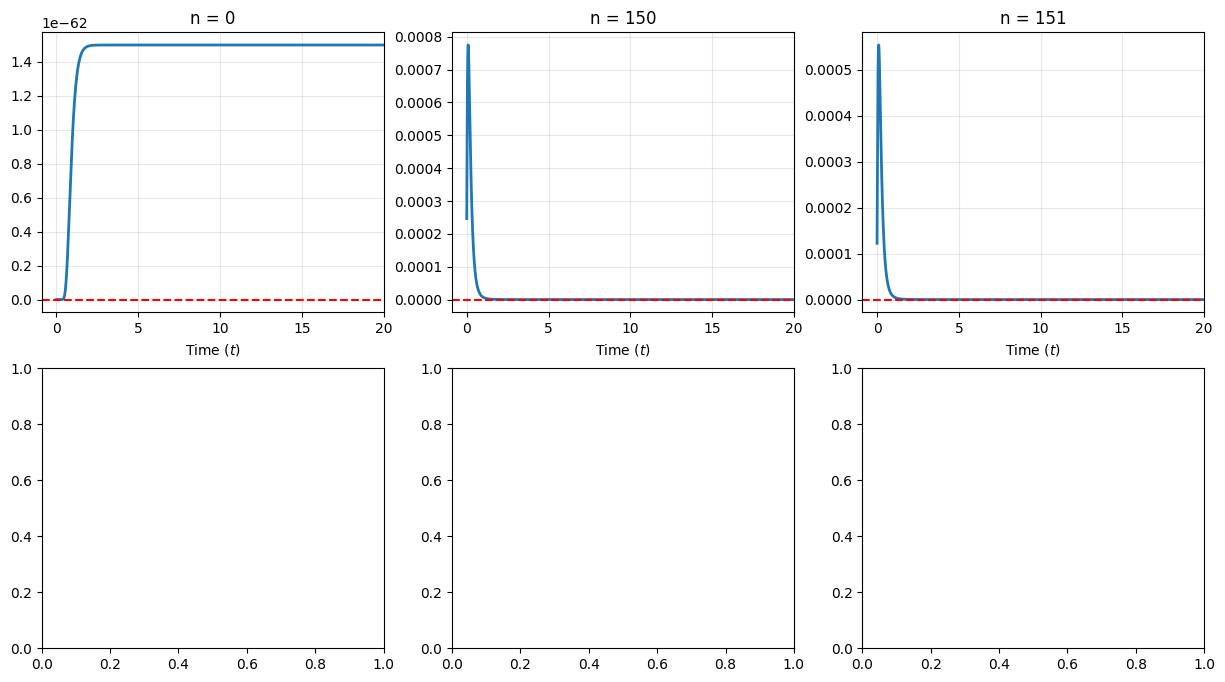

In [250]:
n_to_plot = [0, 150, 151, N-2, N-1, N]

num_plots_n = len(n_to_plot)

# Dynamically calculate grid size
ncols_n = min(3, num_plots_n)
nrows_n = math.ceil(num_plots_n / ncols_n)

# Create the grid with a dynamic figsize
fig, axes = plt.subplots(nrows=nrows_n, ncols=ncols_n, figsize=(5 * ncols_n, 4 * nrows_n))

# Flatten axes to 1D array for easy looping
if num_plots_n == 1:
    axes_n = [axes]
else:
    axes_n = axes.flatten()

def right_bc(t, phi, kplus):
    return U0[-1] * np.exp(phi * kplus * t)

for idx, n in enumerate(n_to_plot):
    ax = axes_n[idx]

    ax.plot(sol.t, sol.y[n,:], linewidth=2)

    if n == N:
        ax.plot(sol.t, right_bc(sol.t, phi, kplus), label=r"Analytical $m(1, t)$", linewidth=2, linestyle="--")
        ax.set_ylim(0, max(sol.y[n,:]) * 1.1)
    else:
        ax.axhline(y=0, color="red", linestyle="--")

    ax.set_xlim(-0.9, 20)

    ax.set_xlabel(r"Time ($t$)")
    ax.set_title(f"n = {n:.0f}")
    ax.grid(True, alpha=0.3)

plt.suptitle("Time dynamics for different lipid classes", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

for empty_idx in range(num_plots, len(axes)):
    axes[empty_idx].set_visible(False)
